<div style="background-color: lightblue; color: black; border: 2px solid black; 
padding: 15px 25px; border-radius: 8px; margin: 10px 0px;">

  <h2 style="color: black; margin: 0px 0px 10px 0px;">
   Testing for Unphysical Precipitation Values in UKCP Local
  </h2>

  <hr style="border: 1px solid black; margin: 10px 0px;">

  <p>In the set of extreme events extracted from UKCP Local (bias-corrected, 
  5km data), some events have maximum precipitation values which are 
  unphysical — i.e., higher than is physically plausible.</p>

  <p><strong>This script tests:</strong></p>
  <ul>
    <li>The number of events per catchment, per ensemble member with an unphysical value</li>
    <li>The number of pixels affected per event</li>
  </ul>

  <div style="background-color: white; border-left: 4px solid orange; 
  padding: 8px 15px; border-radius: 0px 5px 5px 0px; margin-top: 12px;">
    <strong>NB:</strong> The threshold for an "unphysical" value is 
    currently set at <strong>150mm/hr</strong> — selected relatively 
    arbitrarily and may need review.
  </div>

</div>

In [1]:
import numpy as np
import pandas as pd
import re
import time
import gc
import os
import sys
import math
import glob
import datetime
import geopandas as gpd
from shapely.geometry import MultiPolygon
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from collections import Counter

from functions import *
from functions_stage2 import (get_rainfall_cube_subsection,get_rainfall_cube_subsection_notbc, setup_worker_logger, 
                              find_max_precip_location_new, find_temporal_profile_new, maybe_diagnose, analyse_peak_event,
                             plot_cluster_check, plot_n_peaks, get_exceedance_summary, plot_surrounding_ts, check_extremes_across_combos, 
                              plot_surrounding_ts_new, find_problematic_catchment_em_combos, find_problematic_catchment_em_combos_complex)

# ── Config ────────────────────────────────────────────────────────────────────
from config import RAINFALL_CSV_DIR, CATCHMENT_LOOKUP_DICT, OUT_DIR, CATCHMENTS, ENSEMBLE_MEMBERS 

# ── Define which catchments to run ────────────────────────────────────────────────────────────────────
all_catchments = set(CATCHMENT_LOOKUP_DICT.keys())

<div style="background-color: lightblue; color: black;  border: 2px solid black; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;"><h3 style="color: black; margin: 0px;"> Find catchment, ensemble member combinations with values >150mm/hr </h3>

  <p>For each catchment–ensemble member combination:</p>
  <ul>
    <li>Find the number of events exceeding the <strong>150mm/hr</strong> threshold</li>
    <li>Calculate this as a proportion of the total number of events</li>
  </ul>
    
<div style="background-color: white; border-left: 4px solid orange; 
  padding: 8px 15px; border-radius: 0px 5px 5px 0px; margin-top: 12px;">
This shows that for affected catchments the number of events affected are not insignificant: of the 66 instances of a catchment/ensemble member combination which appear in results_df ~50% have more than 10% of the events with unphysical values, and some have up to almost 50%.    
  </div>    

  <p>Also finds, for the highest peak value in each catchment:</p>
  <ul>
    <li>The number of timesteps which are unphysical (in any catchment cell) </li>
    <li>The number of cells which experience any unphysical values within 10 timesteps of the highest unphysical value </li>
    <li>The total number of cells in any cell, at any timestep (within 10 timesteps of the highest unphysical value) which are unphysical </li>     
      <li> The maximum number of cells experiencing an unphysical value concurrently </li>
      <li> The maximum number of timesteps for one cell which experience an unphysical value
  </ul>
<div style="background-color: white; border-left: 4px solid orange; 
padding: 8px 15px; border-radius: 0px 5px 5px 0px; margin-top: 12px;">
This shows that the unphysical values do not always occur in isolation. There are frequently either (i) other grid cells nearby affected, or (ii) other timesteps affected before or after.
   
  </div>   
</div>

In [2]:
results_df, problematic_catchment_names, problematic_catchment_nums = find_problematic_catchment_em_combos_complex(all_catchments, CATCHMENT_LOOKUP_DICT, ENSEMBLE_MEMBERS, RAINFALL_CSV_DIR)
# results_df.sort_values(by='% Problematic', ascending = False)[:5]


Done. 66 problematic combinations across 22 catchments.
Outputs saved to: problematic_catchment_outputs/


In [3]:
# Get list of catchment_num, ensemble_member combos
problematic_combos  =[]
for num, row in results_df.iterrows():
    problematic_combos.append((row['Catchment No.'], row['Ensemble Member']))

In [4]:
# Check number of problematic events
lengths = 0
for row in results_df["Problematic Event Nums"]:
    lengths+=len(row)
lengths

963

<div style="background-color: lightblue; color: black;  border: 2px solid black; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;"><h3 style="color: black; margin: 0px;"> Are events with unphysical values only selected because of that unphysical value, or would they have been selected anyway? </h3>

  <p>For each catchment–ensemble member combination:</p>
  <ul>
    <li>Compare bias-corrected and non-bc version of event </li>
    <li>Check whether an extreme value is still present in non-bc event</li>
  </ul>
    
<div style="background-color: white; border-left: 4px solid orange; 
  padding: 8px 15px; border-radius: 0px 5px 5px 0px; margin-top: 12px;">
This shows that: for event's with an unphysical value: in the non-bias corrected data, generally there is no extreme value present in the event. Also, the shape of the event when plotted over time seems to often be completely different. When the same testing is done for events without unphysical values: the bias corrected and non-bias-corrected data are similar. The peak value occurs in the same timestep and the overall temporal shape of the event remains the same.
  </div>    
</div>

WARNING THIS IS VERY SLOW TO RUN

In [5]:
# results = check_extremes_across_combos(results_df, plot=False)
# results.to_csv("testing.csv", index=False)
testing=pd.read_csv("testing.csv")

In [ ]:
# results['peak_timestep_agrees'].value_counts(dropna=False)
# plt.hist(results['max_value_nonbc'])

For a smaller number of events make a plot comparing the event in the bias-corrected and non-bias-corrected data:
 - Y-Axis: bias corrected data
 - X-Axis: non-bias corrected data
 
NB: scale of two axes is not the same (in order to check whether if shape, if not scale, are the same

 Catchment number: 104


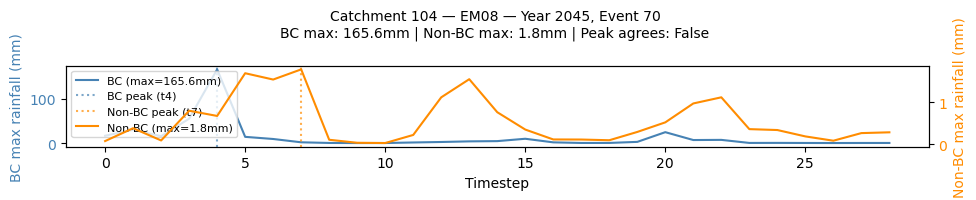

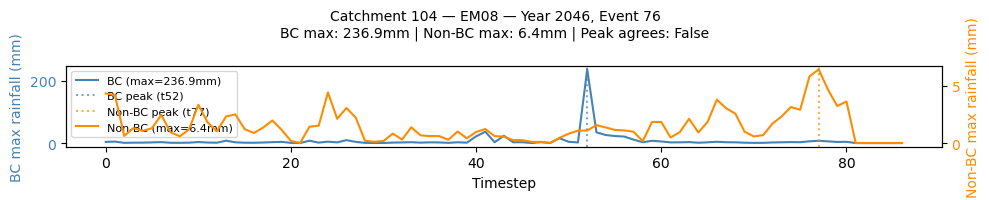

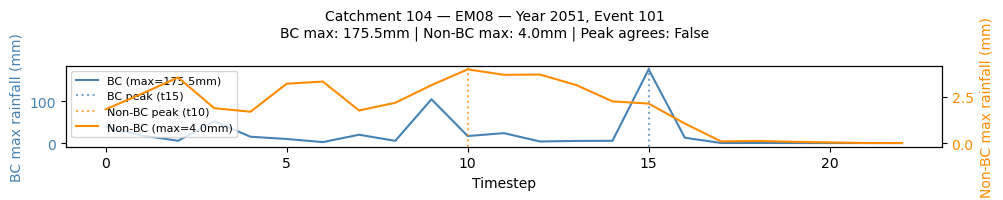

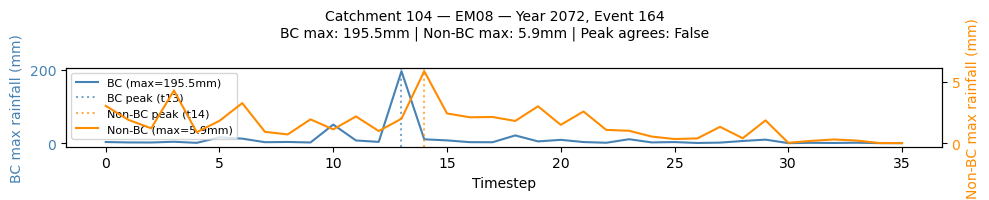

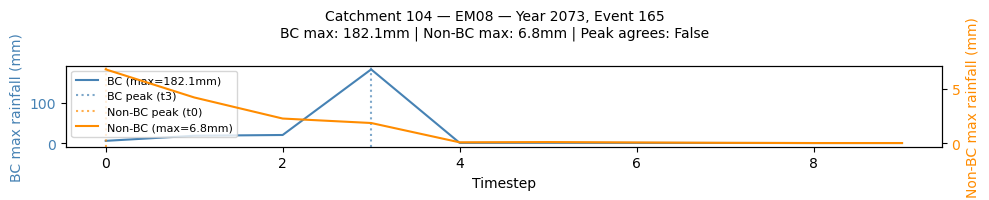

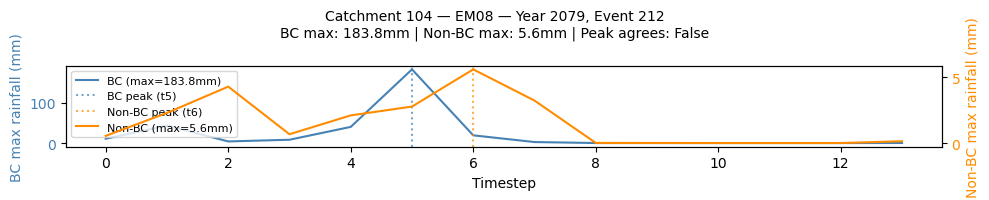

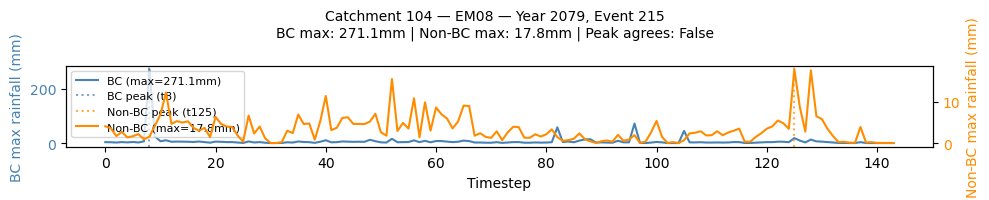

 Catchment number: 104


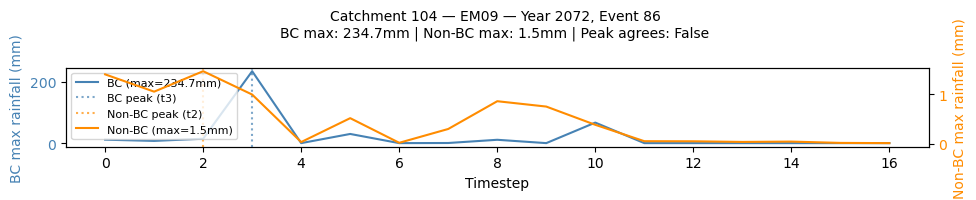

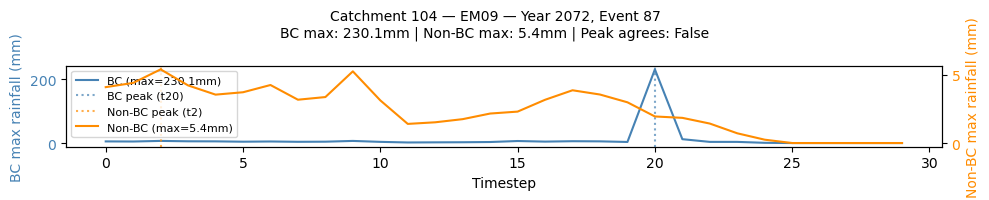

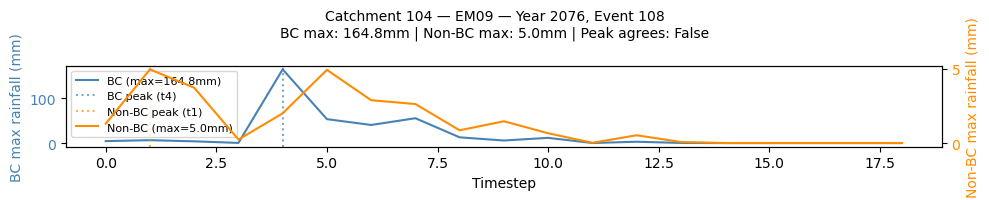

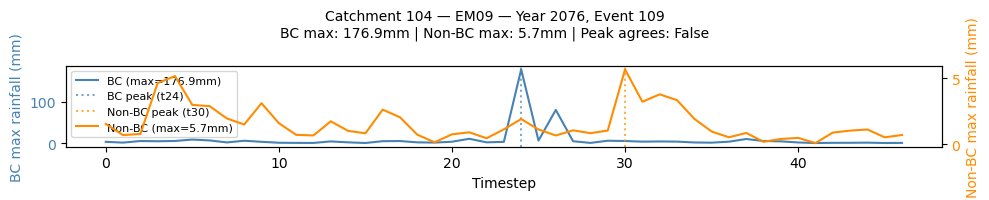

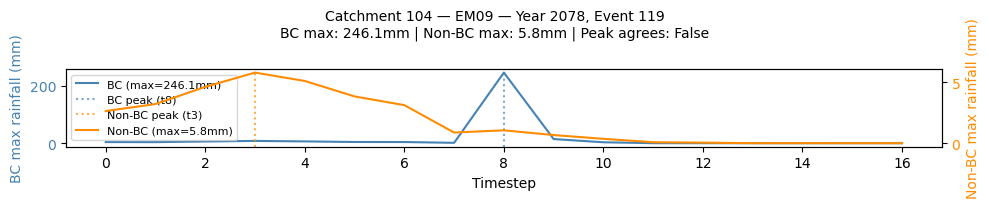

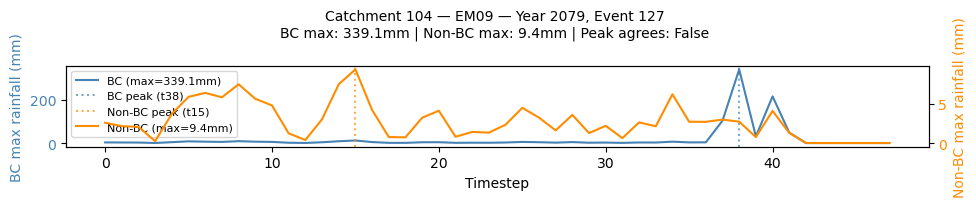

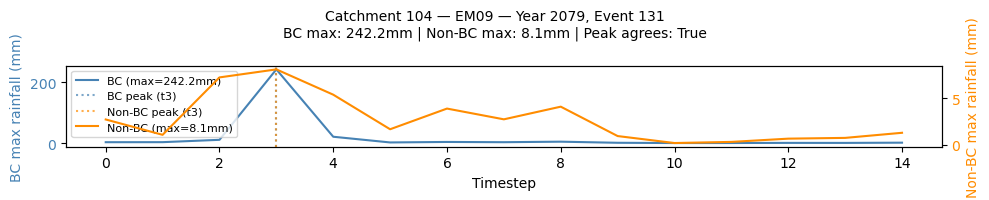

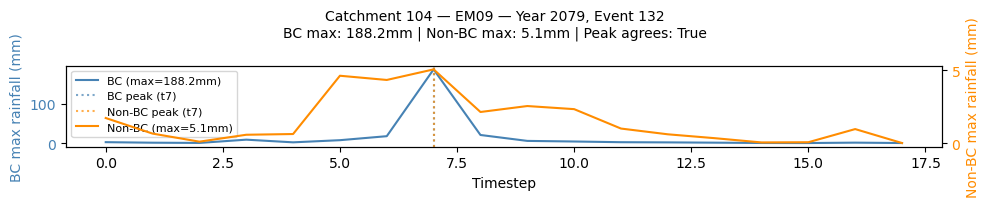

In [11]:
results = check_extremes_across_combos(results_df[3:5], plot=True)

---

Test the same plot for 'normal' events (e.g., no unphysical values)

---

 Catchment number: 20


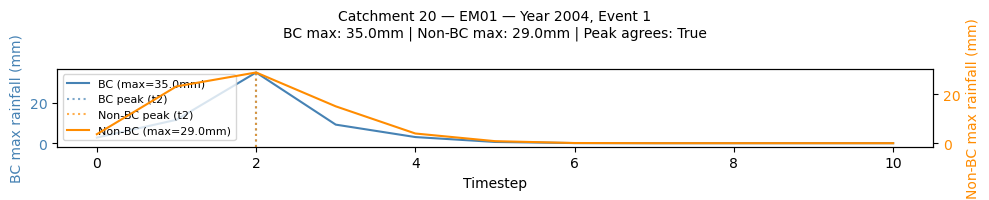

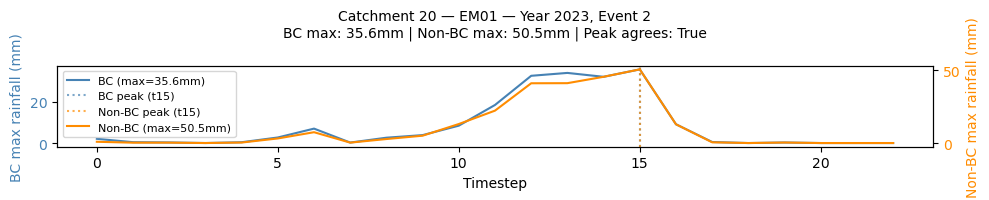

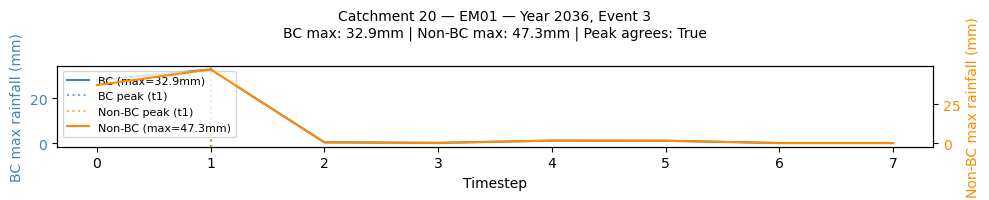

 Catchment number: 20


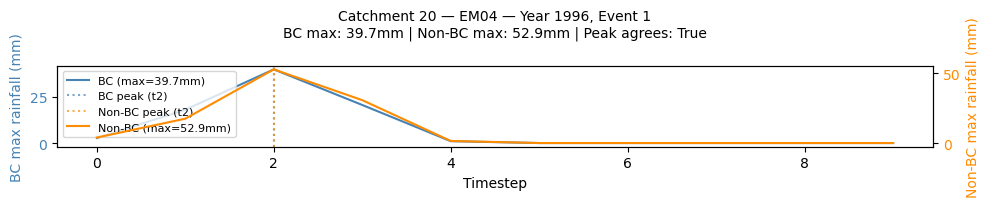

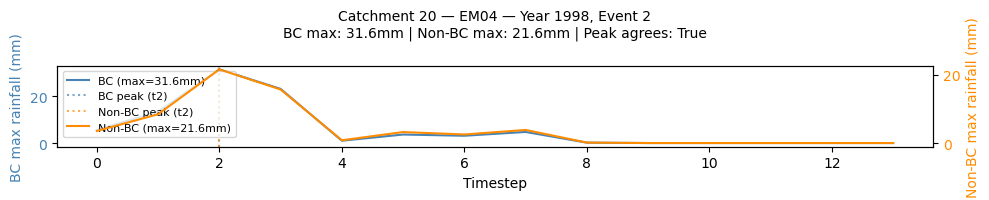

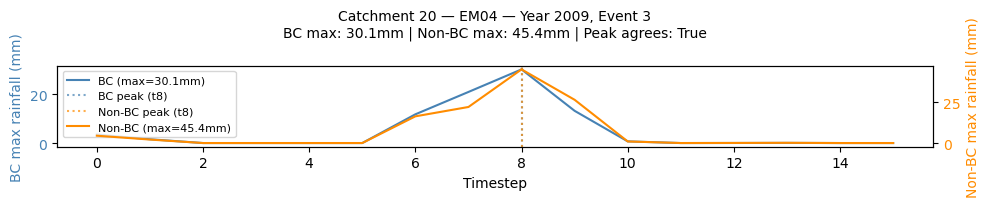

 Catchment number: 20


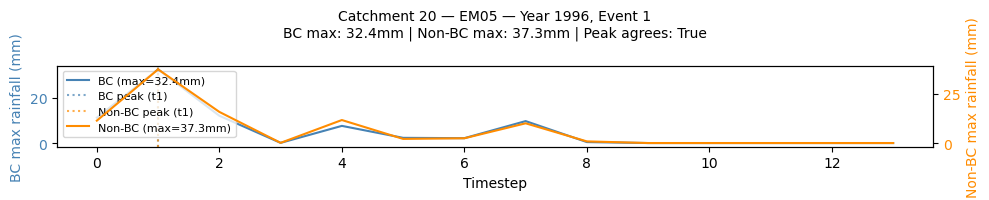

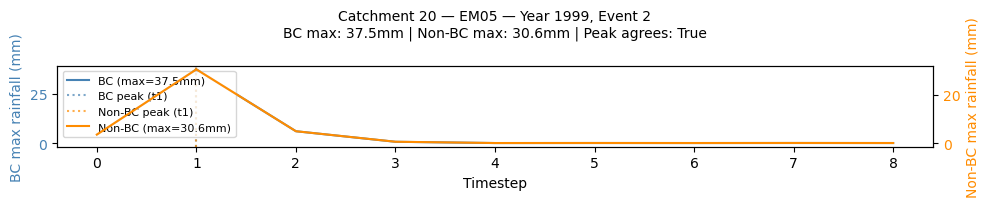

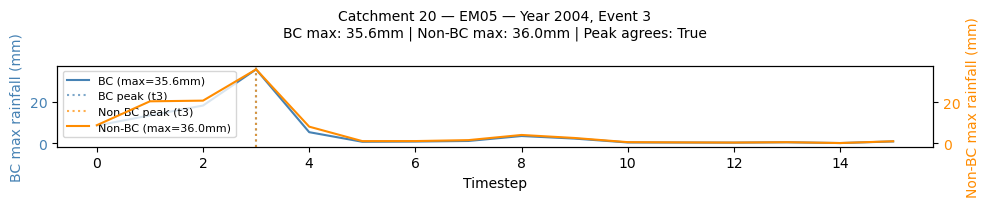

In [39]:
# Get list of catchment_num, ensemble_member combos
combos  =[]
for em in ['01', '04', '05', ]:
    combos.append(('20', em, [1,2,3]))
combos_df = pd.DataFrame(combos, columns = ['Catchment No.', 'Ensemble Member', 'Problematic Event Nums'])
results2 = check_extremes_across_combos(combos_df, plot=True)

<div style="background-color: lightblue; color: black;  border: 2px solid black; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;"><h3 style="color: black; margin: 0px;"> Plot location of catchments with problematic peaks </h3>

Plots a spatial plot showing affected catchments, coloured by how many EMs have problems (NB: not by the total number of events across ensemble members (maybe this'd be more useful)
</div>

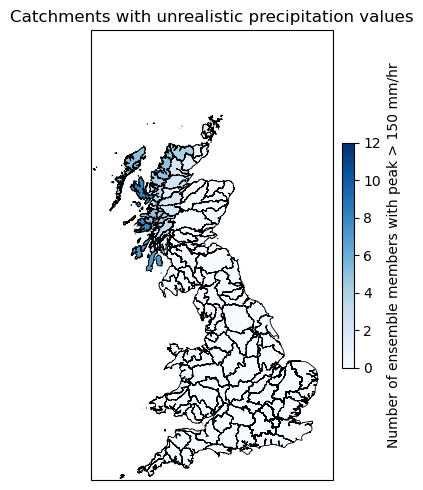

In [3]:
# Count how many ensemble members are problematic per catchment
ens_counts = Counter(problematic_catchment_nums)  # {catchment_num: count}

# Colourmap setup
max_count = len(ENSEMBLE_MEMBERS)
cmap      = cm.Blues
norm      = mcolors.Normalize(vmin=0, vmax=max_count)

fig, ax = plt.subplots(figsize=(5, 5), subplot_kw={'projection': ccrs.OSGB()})

for catchment_num in CATCHMENTS['HA_NUM'].unique():
    boundary_gdf   = CATCHMENTS[CATCHMENTS['HA_NUM'] == str(catchment_num)]
    CATCHMENT_POLY = boundary_gdf.geometry.iloc[0]
    count          = ens_counts.get(catchment_num, 0)  # 0 if not problematic
    facecolor      = cmap(norm(count))
    ax.add_geometries([CATCHMENT_POLY], crs=ccrs.OSGB(), 
                      facecolor=facecolor, edgecolor='black', linewidth=0.6)

# Add colourbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Number of ensemble members with peak > 150 mm/hr', 
             shrink=0.5, pad=0.02)

ax.set_title('Catchments with unrealistic precipitation values')
plt.tight_layout()
plt.show()

<div style="background-color: lightblue; color: black;  border: 2px solid black; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;">
<h3 style="color: black; margin: 0px;"> Testing results for one catchment: Catchment 94 (Loch Maree Group) </h3>

Two test plots: 
1. A spatial plot of the catchment for each of 9 events which for this catchment/EM combination had unphysical values
<div style="background-color: white; border-left: 4px solid orange; 
  padding: 8px 15px; border-radius: 0px 5px 5px 0px; margin-top: 12px;">
    This suggests that it’s not always the same grid cell affected in different instances of the unphysical values (although some grid cells do seem to be over represented)  </div>    
2. Plot containing both (i) Plotted timeseries including the timesteps before and after the unphysical value in the grid cell in which it happened; and (ii) Spatial plot of values across the whole catchment for the 5 timesteps both before and after the unphysical value.
<div style="background-color: white; border-left: 4px solid orange; 
  padding: 8px 15px; border-radius: 0px 5px 5px 0px; margin-top: 12px;">
This suggests that often other unphysical values occur in the surrounding cells/timesteps to the peak. </div>    
   
**Additionally**: plot the same plots using data that hasn't been bias corrected:  

<div style="background-color: white; border-left: 4px solid orange; 
  padding: 8px 15px; border-radius: 0px 5px 5px 0px; margin-top: 12px;">
    This suggests that the problem is introduced by the bias correction. No unphysical values are present in the non-bias corrected data at the times and locations where they appear in bias-corrected data.  </div>    

</div>

In [4]:
catchment_num = '94' #'94'
ens_num = '07'
catchment_name  = CATCHMENT_LOOKUP_DICT[str(catchment_num)]
print(catchment_name)
rainfall_cube_dir_bc = f"/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/{ens_num}/"
rainfall_cube_dir_notbc = f"/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Precipitation/Hourly/5km/Ens_{ens_num}/"

LochMareegroup


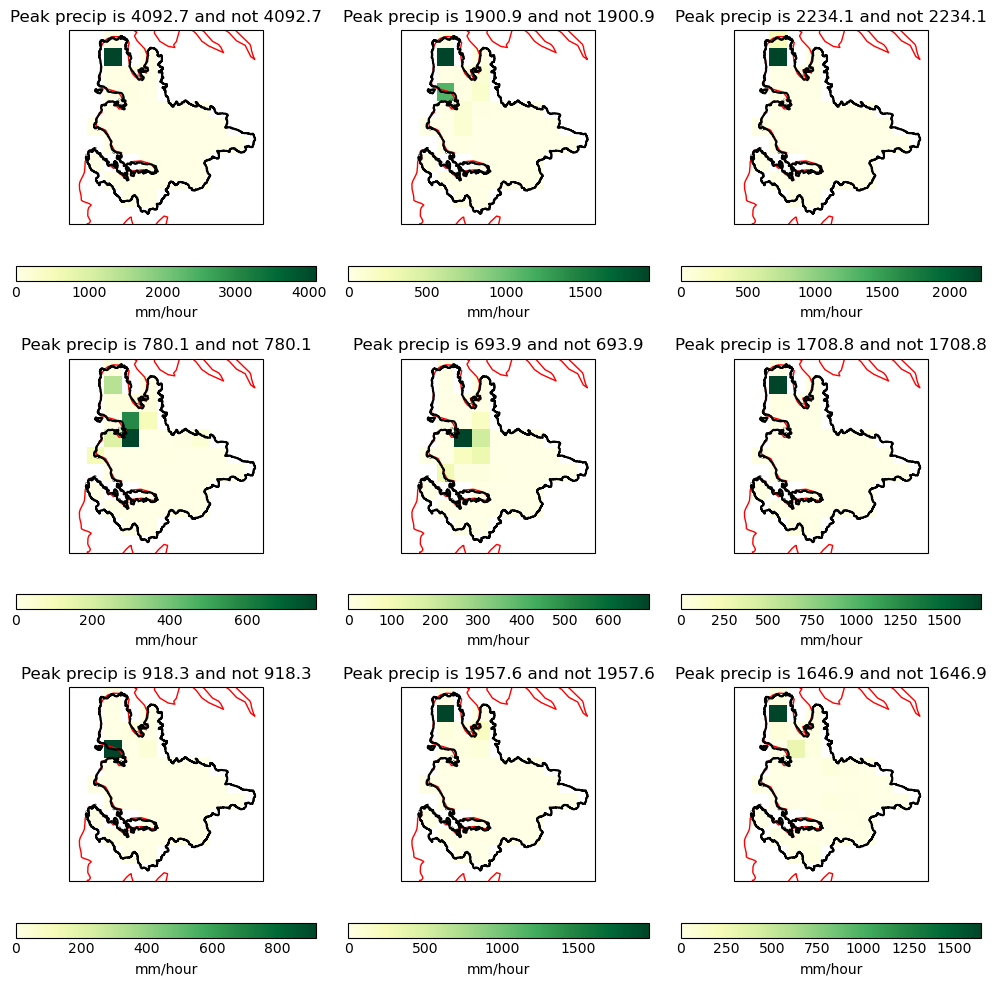

In [5]:
plot_n_peaks(rainfall_cube_dir_bc, ens_num = ens_num, catchment_num= catchment_num, n= 9, bc=True)

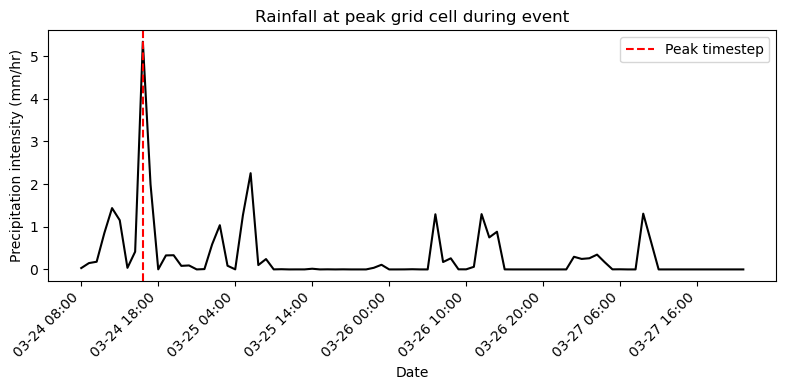


--- Exceedance summary (±10 timesteps around peak) ---
  Timesteps with ≥1 cell > 150mm : 0
  Cells exceeding in ≥1 timestep : 0
  Total (t, cell) exceedances    : 0
  Max cells in a single timestep : 0
  Cells-per-timestep breakdown   : [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


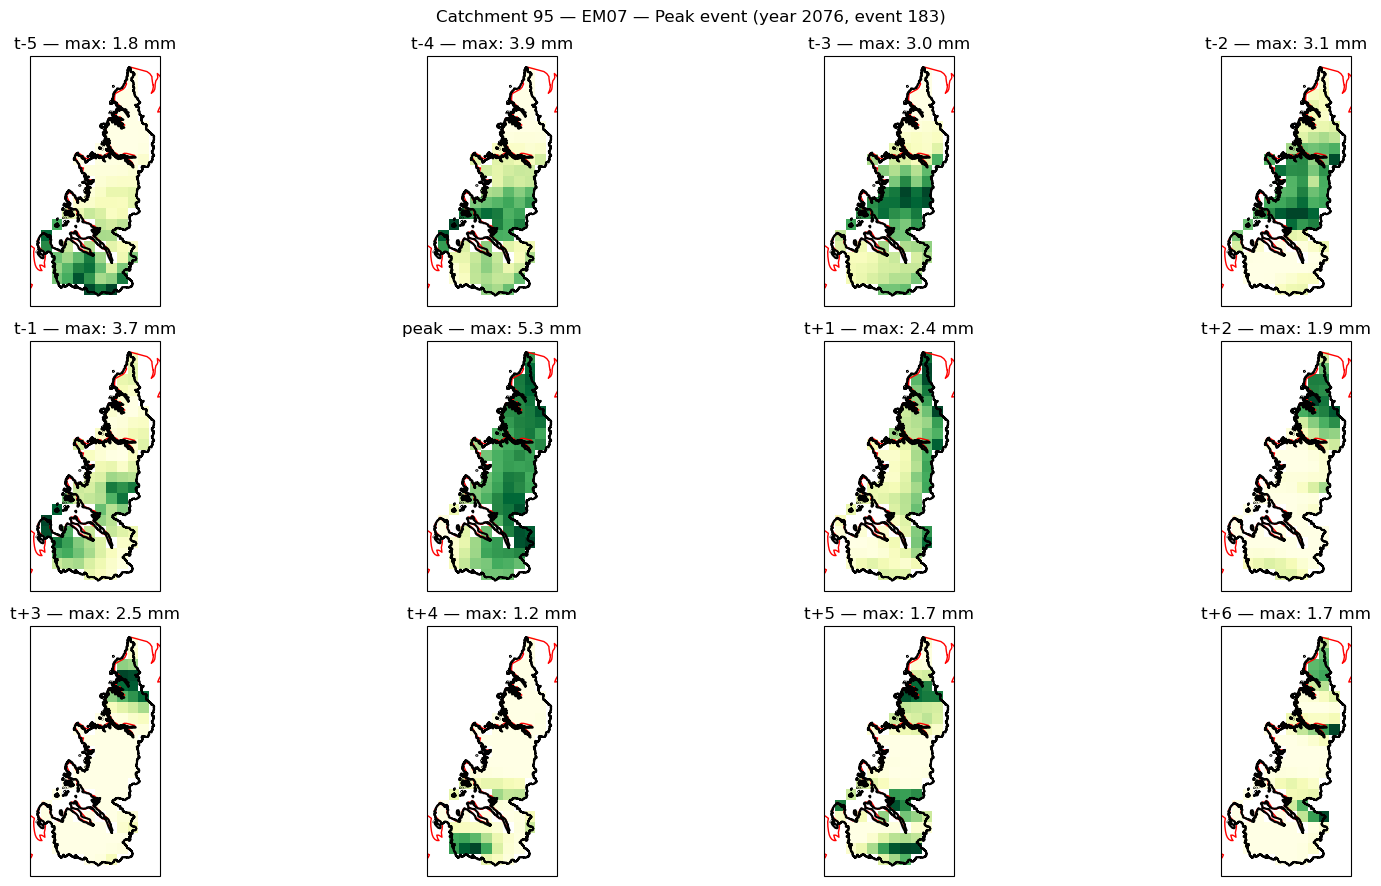

In [14]:
plot_surrounding_ts_new(rainfall_cube_dir_notbc, catchment_num, ens_num, bc=False)

In [ ]:
# Use the rainfall events csv to extract the event from the cube

In [ ]:
def plot_surrounding_ts_new (rainfall_cube_dir, catchment_num, ens_num, bc=True):
    catchment_name  = CATCHMENT_LOOKUP_DICT[str(catchment_num)]
    boundary_gdf    = CATCHMENTS[CATCHMENTS['HA_NUM'] == str(catchment_num)]
    CATCHMENT_POLY = boundary_gdf.geometry.iloc[0]
    # catchment_gdf = gpd.GeoDataFrame(geometry=[CATCHMENT_POLY], crs=waterbodies_df.crs)
    # waterbodies_in_catchment = gpd.sjoin(waterbodies_df, catchment_gdf, how='inner', predicate='within')
    full_rain_cube = get_rainfall_cube_subsection(2015, '01', f"/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/01/", 1, 2)
    FULL_MASK_2D   = mask_cube_with_catchment_full_grid(full_rain_cube[0], CATCHMENT_POLY, method='center_point')
    year_cube, mask_x_offset, mask_y_offset = subset_cube_to_bbox(full_rain_cube, CATCHMENT_POLY, buffer=0)
    ny_sub = year_cube.shape[1]
    nx_sub = year_cube.shape[2]
    mask_2d_sub = FULL_MASK_2D[mask_y_offset:mask_y_offset + ny_sub, mask_x_offset:mask_x_offset + nx_sub]


    rainfall_events  = pd.read_csv(RAINFALL_CSV_DIR + f"{catchment_name}_{ens_num}_full_events_with_event_nums.csv")
    rainfall_events['event_num']  = range(1, len(rainfall_events) + 1)
    rainfall_events['hydro_year'] = rainfall_events['start_year'].where(rainfall_events['start_month'] != 12,
            rainfall_events['start_year'] + 1)

    event_details_cache = {
        ev: get_rainfall_event_details(rainfall_events, ev)
        for ev in rainfall_events['event_num']}

    # ── Get single peak event only ────────────────────────────────────────────
    peak_event_row = rainfall_events.nlargest(1, 'peaks').iloc[0]
    year           = int(peak_event_row['hydro_year'])
    event_num      = int(peak_event_row['event_num'])
    event_details  = event_details_cache[event_num]

    # ── Load cube for the peak event, with extra timesteps either side ────────
    BUFFER = 3
    if bc ==True:
        year_cube = get_rainfall_cube_subsection(
            year, ens_num, rainfall_cube_dir,
            event_details['start_idx'] - 1 - BUFFER,
            event_details['stop_idx']  + BUFFER)
    else:
        year_cube = get_rainfall_cube_subsection_notbc(
            year, ens_num, rainfall_cube_dir,
            event_details['start_idx'] - 1 - BUFFER,
            event_details['stop_idx']  + BUFFER)   
    
    year_cube.data = np.where(FULL_MASK_2D, year_cube.data, np.nan)
    year_cube, x_offset, y_offset = subset_cube_to_bbox(year_cube, CATCHMENT_POLY, buffer=0)

    # ── Find the peak timestep index within this cube ─────────────────────────
    max_time_idx = np.unravel_index(np.nanargmax(year_cube.data), year_cube.data.shape)[0]
    
    # ── Build the 7 timestep indices to plot (clamped to cube bounds) ─────────
    n_times      = year_cube.shape[0]
    offsets      = [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4,5,6 ]
    plot_indices = [np.clip(max_time_idx + o, 0, n_times - 1) for o in offsets]

    # ── Validate event ────────────────────────────────────────────────────────
    this_event_results = find_max_precip_location_new(
        year_cube, event_details['start_idx'], event_details['stop_idx'],
        x_offset=x_offset, y_offset=y_offset, mask_2d=mask_2d_sub)
    this_event_results['max_precip_from_csv'] = event_details['max_precip_from_csv']

    time_coord    = year_cube.coord('time')
    time_from_cube = time_coord.units.num2date(np.floor(time_coord.points[0]))
    time_from_csv  = cftime.Datetime360Day(
        event_details['yr'], event_details['month'],
        event_details['day'], event_details['hour'])
    this_event_results['time_mismatch'] = (time_from_cube != time_from_csv)

    # ── NEW: exceedance summary around peak ───────────────────────────────────
    exceedance_summary, window_indices = get_exceedance_summary(
        year_cube, max_time_idx, threshold=150, window=10
    )
    this_event_results.update(exceedance_summary)    
    

    #Get 1D cube, just at the location of the peak
    rainfall_at_peak  = get_data_at_peak_cell(year_cube, this_event_results, 'x_idx', 'y_idx')
    
    #Extract various temporal profile results
    temp_profile_dict = find_temporal_profile_new(rainfall_at_peak, this_event_results, plot=True)

    # ── Plot: 7 subplots centred on the peak timestep ─────────────────────────
    fig, axs = plt.subplots(ncols=4, nrows=3, figsize=(18, 9),
                            subplot_kw={'projection': ccrs.OSGB()})
    axs = axs.flatten()

    for ax_i, (offset, t_idx) in enumerate(zip(offsets, plot_indices)):
        label = "peak" if offset == 0 else f"t{offset:+d}"

        # Max precip value across the catchment at this timestep
        timestep_max = np.nanmax(year_cube[t_idx, :, :].data)
        iplt.pcolormesh(year_cube[t_idx, :, :], axes=axs[ax_i],
                        cmap='YlGn', edgecolor='none', linewidth=0.5)
        axs[ax_i].coastlines(resolution='10m', color='red')
        axs[ax_i].add_geometries([CATCHMENT_POLY], crs=ccrs.OSGB(),
                                  facecolor='none', edgecolor='black', linewidth=1.5)
        axs[ax_i].set_title(f"{label} — max: {timestep_max:.1f} mm")

    # Hide the unused 8th subplot (4×2 grid has 8 slots, we use 7)
    # axs[7].set_visible(False)

    fig.suptitle(f"Catchment {catchment_num} — EM{ens_num} — Peak event (year {year}, event {event_num})",
                 fontsize=12)
    fig.tight_layout()
    
#     # ── Optional: add a subplot showing timesteps-per-cell spatial map ────────
#     # (tack onto your existing fig after the main loop)
#     fig2, ax2 = plt.subplots(figsize=(6, 5), subplot_kw={'projection': ccrs.OSGB()})
#     persist_cube = year_cube[0, :, :].copy()           # borrow a single slice
#     persist_cube.data = exceedance_summary["timesteps_per_cell_2d"].astype(float)
#     persist_cube.data[persist_cube.data == 0] = np.nan # mask zeros for clarity

#     iplt.pcolormesh(persist_cube, axes=ax2, cmap='OrRd', vmin=1, vmax=10)
#     ax2.coastlines(resolution='10m', color='grey')
#     ax2.add_geometries([CATCHMENT_POLY], crs=ccrs.OSGB(),
#                        facecolor='none', edgecolor='black', linewidth=1.5)
#     ax2.set_title(
#         f"No. timesteps (of ±10) where cell > {150}mm\n"
#         f"Catchment {catchment_num} — EM{ens_num} — Event {event_num}"
#     )
#     fig2.colorbar(ax2.collections[0], ax=ax2, label="N timesteps exceeding threshold")
#     fig2.tight_layout()

    # ── Print summary ─────────────────────────────────────────────────────────
    print(f"\n--- Exceedance summary (±10 timesteps around peak) ---")
    print(f"  Timesteps with ≥1 cell > 150mm : {exceedance_summary['n_timesteps_any_exceedance']}")
    print(f"  Cells exceeding in ≥1 timestep : {exceedance_summary['n_cells_any_exceedance']}")
    print(f"  Total (t, cell) exceedances    : {exceedance_summary['total_exceedances']}")
    print(f"  Max cells in a single timestep : {exceedance_summary['max_cells_in_one_timestep']}")
    print(f"  Cells-per-timestep breakdown   : {exceedance_summary['cells_per_timestep']}")  

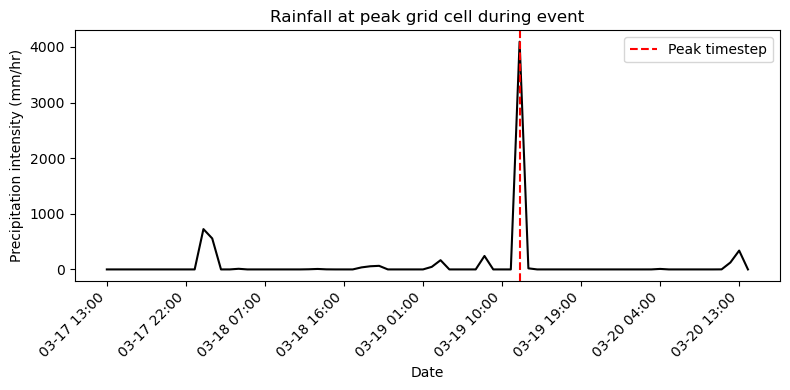


--- Exceedance summary (±10 timesteps around peak) ---
  Timesteps with ≥1 cell > 150mm : 4
  Cells exceeding in ≥1 timestep : 2
  Total (t, cell) exceedances    : 4
  Max cells in a single timestep : 1
  Cells-per-timestep breakdown   : [0 1 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0]


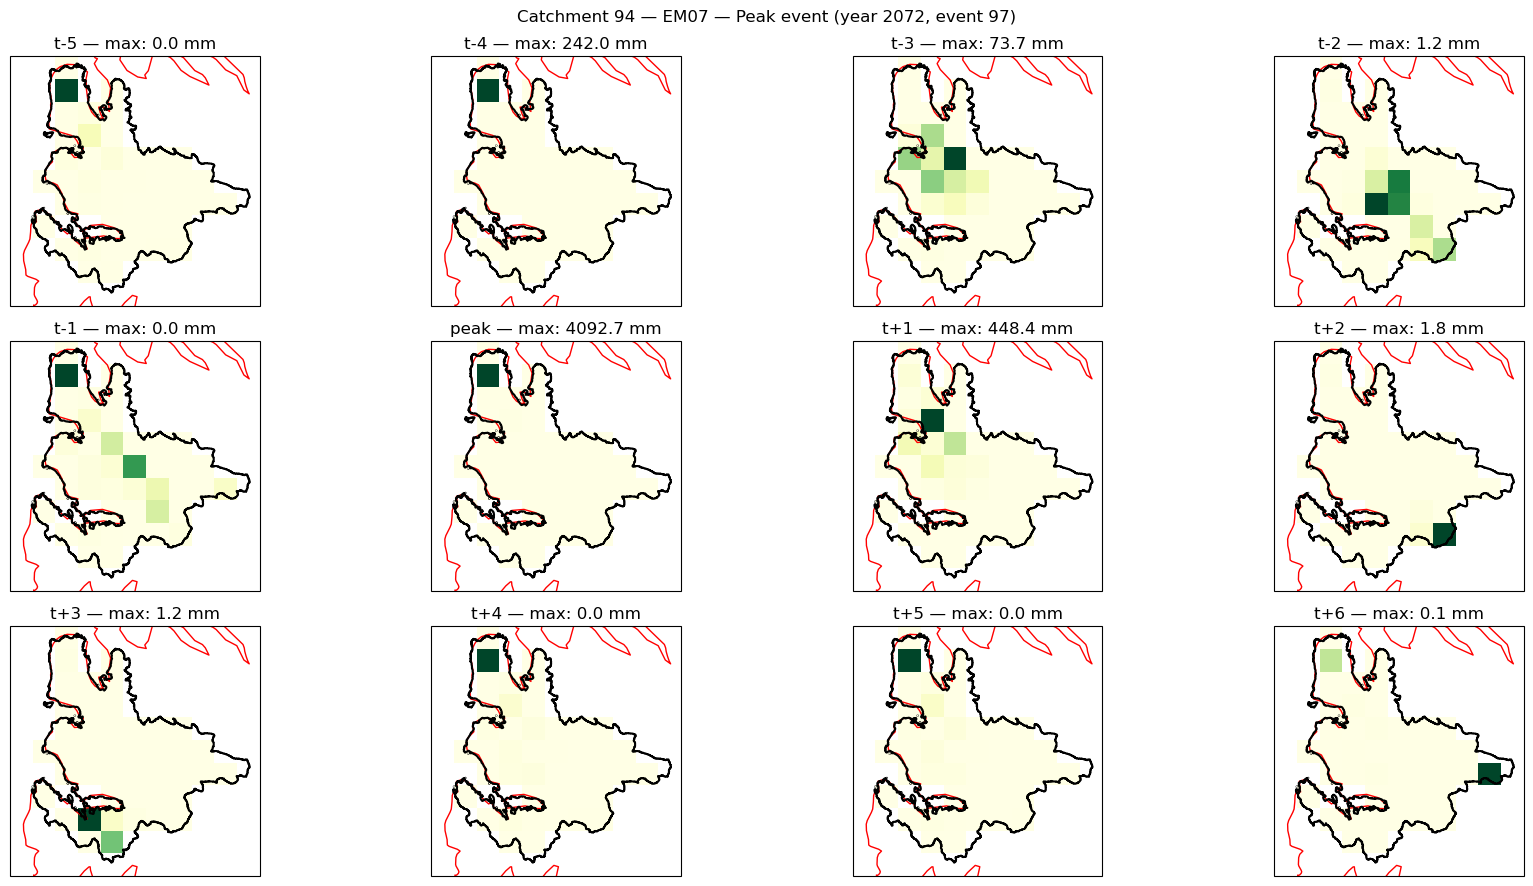

In [6]:
plot_surrounding_ts_new(rainfall_cube_dir_bc, catchment_num, ens_num, bc=True)

<div style="background-color: #e8f4f8; color: black; border-left: 4px solid steelblue; 
padding: 10px 20px; border-radius: 0px 5px 5px 0px; margin: 10px 20px;">
What happens if plot same plot using data that hasn't been bias corrected? 

</div>

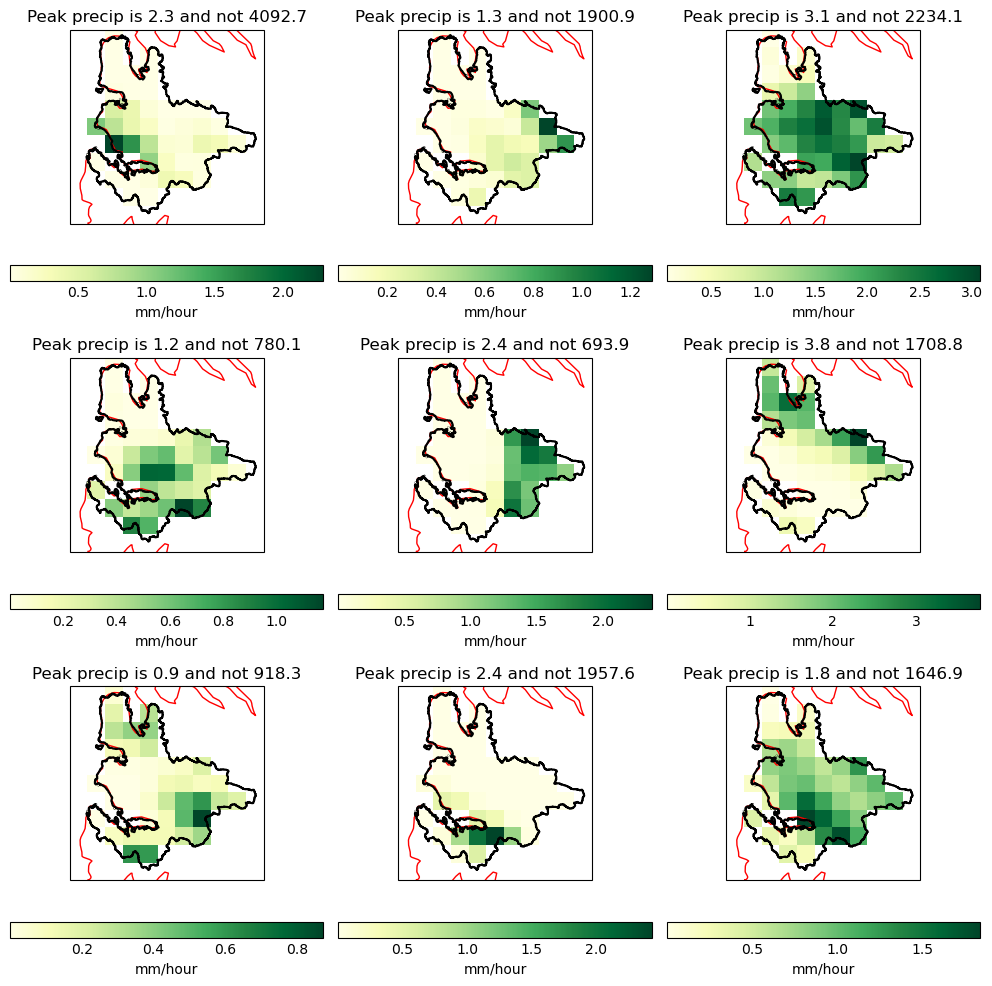

In [7]:
plot_n_peaks(rainfall_cube_dir_notbc, ens_num = ens_num, catchment_num= catchment_num, n= 9, bc=False)

<div style="background-color: #e8f4f8; color: black; border-left: 4px solid steelblue; 
padding: 10px 20px; border-radius: 0px 5px 5px 0px; margin: 10px 20px;">
Check all events for this catchment/ensemble member combination: if bias corrected data would the event still be extreme?

</div>

In [26]:
def plot_bc_vs_nonbc_comparison(rainfall_cube_dir_bc, rainfall_cube_dir_nonbc, catchment_num, ens_num):
    catchment_name = CATCHMENT_LOOKUP_DICT[str(catchment_num)]
    boundary_gdf   = CATCHMENTS[CATCHMENTS['HA_NUM'] == str(catchment_num)]
    CATCHMENT_POLY = boundary_gdf.geometry.iloc[0]

    # ── Shared mask setup (same grid for both) ────────────────────────────────
    full_rain_cube = get_rainfall_cube_subsection(2015, '01', f"/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/01/", 1, 2)
    FULL_MASK_2D   = mask_cube_with_catchment_full_grid(full_rain_cube[0], CATCHMENT_POLY, method='center_point')
    year_cube, mask_x_offset, mask_y_offset = subset_cube_to_bbox(full_rain_cube, CATCHMENT_POLY, buffer=0)
    ny_sub  = year_cube.shape[1]
    nx_sub  = year_cube.shape[2]
    mask_2d_sub = FULL_MASK_2D[mask_y_offset:mask_y_offset + ny_sub, mask_x_offset:mask_x_offset + nx_sub]

    # ── Load events CSV and find peak event ───────────────────────────────────
    rainfall_events = pd.read_csv(RAINFALL_CSV_DIR + f"{catchment_name}_{ens_num}_full_events_with_event_nums.csv")
    rainfall_events['event_num']  = range(1, len(rainfall_events) + 1)
    rainfall_events['hydro_year'] = rainfall_events['start_year'].where(
        rainfall_events['start_month'] != 12,
        rainfall_events['start_year'] + 1)

    event_details_cache = {
        ev: get_rainfall_event_details(rainfall_events, ev)
        for ev in rainfall_events['event_num']}

    peak_event_row = rainfall_events.nlargest(1, 'peaks').iloc[0]
    year           = int(peak_event_row['hydro_year'])
    event_num      = int(peak_event_row['event_num'])
    event_details  = event_details_cache[event_num]

    # ── Load both cubes for the same event ───────────────────────────────────
    start_idx = event_details['start_idx']
    stop_idx  = event_details['stop_idx']

    def load_and_clip(cube_dir, bc):
        loader = get_rainfall_cube_subsection if bc else get_rainfall_cube_subsection_notbc
        cube = loader(year, ens_num, cube_dir, start_idx, stop_idx)
        cube.data = np.where(FULL_MASK_2D, cube.data, np.nan)
        cube, x_off, y_off = subset_cube_to_bbox(cube, CATCHMENT_POLY, buffer=0)
        return cube, x_off, y_off

    cube_bc,    x_offset, y_offset = load_and_clip(rainfall_cube_dir_bc,   bc=True)
    cube_nonbc, _,        _        = load_and_clip(rainfall_cube_dir_nonbc, bc=False)

    n_times      = cube_bc.shape[0]
    plot_indices = list(range(n_times))   # every timestep in the event
    max_time_idx = np.unravel_index(np.nanargmax(cube_bc.data), cube_bc.data.shape)[0]

    # ── Compute a shared colour scale so both rows are directly comparable ────
    vmin = 0
    vmax = max(
        np.nanmax(cube_bc.data[plot_indices]),
        np.nanmax(cube_nonbc.data[plot_indices])
    )

    # ── Plot: 2 rows (BC top, non-BC bottom), 12 columns ─────────────────────
    n_cols = n_times
    fig, axs = plt.subplots(nrows=2, ncols=n_cols,
                            figsize=(n_cols * 2.5, 7),
                            subplot_kw={'projection': ccrs.OSGB()})
    
    for row_i, (cube, label_prefix) in enumerate([(cube_bc, "BC"), (cube_nonbc, "Non-BC")]):
        
        for col_i, t_idx in enumerate(plot_indices):
            ax      = axs[row_i, col_i]
            ts_max  = np.nanmax(cube[t_idx, :, :].data)
            # Mark the peak column so it's still easy to spot
            t_label = f"t{t_idx}" + (" ★" if t_idx == max_time_idx else "")
   
            iplt.pcolormesh(cube[t_idx, :, :], axes=ax,
                            cmap='YlGn', vmin=vmin, vmax=vmax,
                            edgecolor='none', linewidth=0.5)
            ax.coastlines(resolution='10m', color='red')
            ax.add_geometries([CATCHMENT_POLY], crs=ccrs.OSGB(),
                              facecolor='none', edgecolor='black', linewidth=1.5)

            # Only label timestep on the top row to avoid clutter
            if row_i == 0:
                ax.set_title(f"{t_label}", fontsize=8)
            ax.set_xlabel(f"{ts_max:.1f} mm", fontsize=7)

        # Row label on the leftmost axis
        axs[row_i, 0].text(-0.15, 0.5, label_prefix,
                           transform=axs[row_i, 0].transAxes,
                           va='center', ha='right', fontsize=10, fontweight='bold',
                           rotation=90)

    # ── Shared colorbar ───────────────────────────────────────────────────────
    sm = plt.cm.ScalarMappable(cmap='YlGn', norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    fig.colorbar(sm, ax=axs, orientation='vertical',
                 fraction=0.015, pad=0.02, label='Rainfall (mm)')

    fig.suptitle(
        f"BC vs Non-BC — Catchment {catchment_num} — EM{ens_num} — "
        f"Peak event (year {year}, event {event_num})",
        fontsize=12)
    fig.tight_layout()

    # ── Print difference summary at peak timestep ─────────────────────────────
    diff_at_peak = cube_bc[max_time_idx].data - cube_nonbc[max_time_idx].data
    print(f"\n--- BC vs Non-BC diff at peak timestep ---")
    print(f"  BC   peak max : {np.nanmax(cube_bc[max_time_idx].data):.2f} mm")
    print(f"  NonBC peak max: {np.nanmax(cube_nonbc[max_time_idx].data):.2f} mm")
    print(f"  Mean diff     : {np.nanmean(diff_at_peak):.2f} mm")
    print(f"  Max diff      : {np.nanmax(np.abs(diff_at_peak)):.2f} mm")
    
    
    

In [28]:
# rainfall_events = pd.read_csv(RAINFALL_CSV_DIR + f"{catchment_name}_{ens_num}_full_events_with_event_nums.csv")
# rainfall_events

In [31]:
def compare_bc_nonbc_timeseries(rainfall_cube_dir_bc, rainfall_cube_dir_nonbc, catchment_num, ens_num):
    catchment_name = CATCHMENT_LOOKUP_DICT[str(catchment_num)]
    boundary_gdf   = CATCHMENTS[CATCHMENTS['HA_NUM'] == str(catchment_num)]
    CATCHMENT_POLY = boundary_gdf.geometry.iloc[0]

    # ── Mask setup ────────────────────────────────────────────────────────────
    full_rain_cube = get_rainfall_cube_subsection(2015, '01', f"/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/01/", 1, 2)
    FULL_MASK_2D   = mask_cube_with_catchment_full_grid(full_rain_cube[0], CATCHMENT_POLY, method='center_point')

    # ── Find peak event ───────────────────────────────────────────────────────
    rainfall_events = pd.read_csv(RAINFALL_CSV_DIR + f"{catchment_name}_{ens_num}_full_events_with_event_nums.csv")
    rainfall_events['event_num']  = range(1, len(rainfall_events) + 1)
    rainfall_events['hydro_year'] = rainfall_events['start_year'].where(
        rainfall_events['start_month'] != 12, rainfall_events['start_year'] + 1)

    peak_event_row = rainfall_events.nlargest(1, 'peaks').iloc[0]
    year           = int(peak_event_row['hydro_year'])
    event_num      = int(peak_event_row['event_num'])
    event_details  = get_rainfall_event_details(rainfall_events, event_num)

    start_idx = event_details['start_idx']
    stop_idx  = event_details['stop_idx']

    # ── Load both cubes ───────────────────────────────────────────────────────
    def load_spatial_mean(cube_dir, bc):
        loader = get_rainfall_cube_subsection if bc else get_rainfall_cube_subsection_notbc
        cube   = loader(year, ens_num, cube_dir, start_idx, stop_idx)
        cube.data = np.where(FULL_MASK_2D, cube.data, np.nan)
        # Mean over the catchment cells at each timestep
        return np.nanmean(cube.data.reshape(cube.shape[0], -1), axis=1)

    vals_bc    = load_spatial_mean(rainfall_cube_dir_bc,    bc=True)
    vals_nonbc = load_spatial_mean(rainfall_cube_dir_nonbc, bc=False)

    # ── Build dataframe ───────────────────────────────────────────────────────
    timesteps = list(range(len(vals_bc)))
    df = pd.DataFrame(
        [vals_bc, vals_nonbc],
        index=['bc', 'non_bc'],
        columns=timesteps
    )

    return df

In [32]:
compare_bc_nonbc_timeseries(rainfall_cube_dir_bc, rainfall_cube_dir_notbc, catchment_num, ens_num)

,0,1,2,3,4,5,6,7,8,9,...,70,71,72,73,74,75,76,77,78,79
bc,1.111111e+18,1.111111e+18,1.111111e+18,1.111111e+18,1.111111e+18,1.111111e+18,1.111111e+18,1.111111e+18,1.111111e+18,1.111111e+18,...,1.111111e+18,1.111111e+18,1.111111e+18,1.111111e+18,1.111111e+18,1.111111e+18,1.111111e+18,1.111111e+18,1.111111e+18,1.111111e+18
non_bc,1.224830e+00,1.155827e+00,1.116325e+00,1.098016e+00,3.561626e+00,7.649807e-01,3.347932e-01,2.475168e-01,1.232312e-01,4.435214e-01,...,1.922641e-01,1.080299e-01,3.509853e-02,4.609499e-02,1.224124e-03,8.137482e-05,3.255839e-06,2.100872e-06,1.393426e-06,2.510475e-06


<div style="background-color: lightblue; color: black;  border: 2px solid black; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;">
<h3 style="color: black; margin: 0px;"> Testing results for one catchment: Catchment 95 (Laxford Group) </h3>

Two test plots:  
1. A spatial plot of the catchment for each of 9 events which for this catchment/EM combination had unphysical values
<div style="background-color: white; border-left: 4px solid orange; 
  padding: 8px 15px; border-radius: 0px 5px 5px 0px; margin-top: 12px;">
    This suggests that it’s not always the same grid cell affected in different instances of the unphysical values (although some grid cells do seem to be over represented)  </div>    
2. Plot containing both (i) Plotted timeseries including the timesteps before and after the unphysical value in the grid cell in which it happened; and (ii) Spatial plot of values across the whole catchment for the 5 timesteps both before and after the unphysical value.
<div style="background-color: white; border-left: 4px solid orange; 
  padding: 8px 15px; border-radius: 0px 5px 5px 0px; margin-top: 12px;">
This suggests that often other unphysical values occur in the surrounding cells/timesteps to the peak. </div>    
   
**Additionally**: plot the same plots using data that hasn't been bias corrected:  

<div style="background-color: white; border-left: 4px solid orange; 
  padding: 8px 15px; border-radius: 0px 5px 5px 0px; margin-top: 12px;">
    This suggests that the problem is introduced by the bias correction. No unphysical values are present in the non-bias corrected data at the times and locations where they appear in bias-corrected data.  </div>    

</div>

In [8]:
catchment_num = '95' #'94'
ens_num = '07'
catchment_name  = CATCHMENT_LOOKUP_DICT[str(catchment_num)]
print(catchment_name)

rainfall_cube_dir_bc = f"/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/{ens_num}/"
rainfall_cube_dir_notbc = f"/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Precipitation/Hourly/5km/Ens_{ens_num}/"

LaxfordGroup


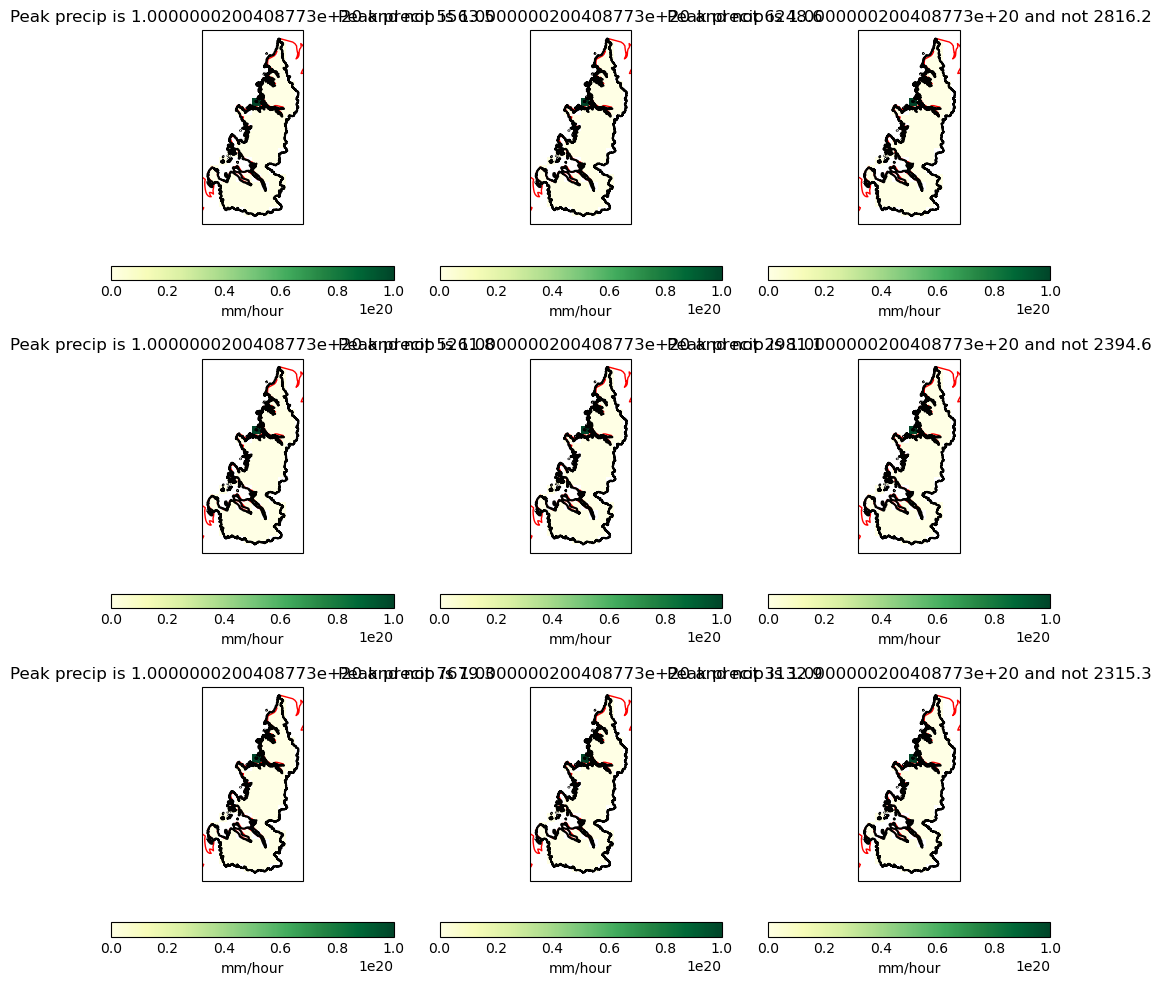

In [9]:
plot_n_peaks(rainfall_cube_dir_bc, ens_num = ens_num, catchment_num= catchment_num, bc=True)

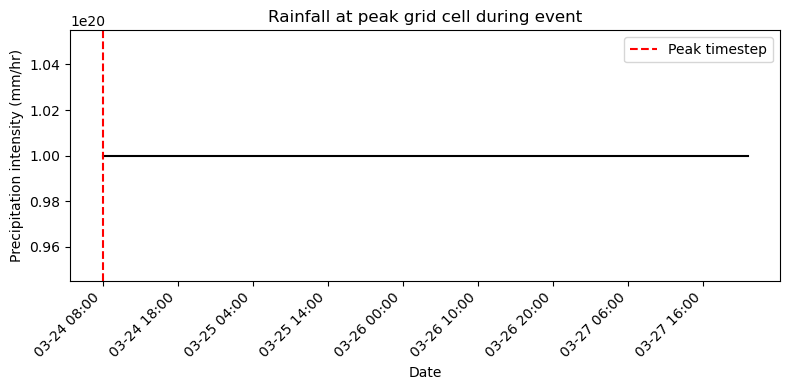


--- Exceedance summary (±10 timesteps around peak) ---
  Timesteps with ≥1 cell > 150mm : 11
  Cells exceeding in ≥1 timestep : 1
  Total (t, cell) exceedances    : 11
  Max cells in a single timestep : 1
  Cells-per-timestep breakdown   : [1 1 1 1 1 1 1 1 1 1 1]


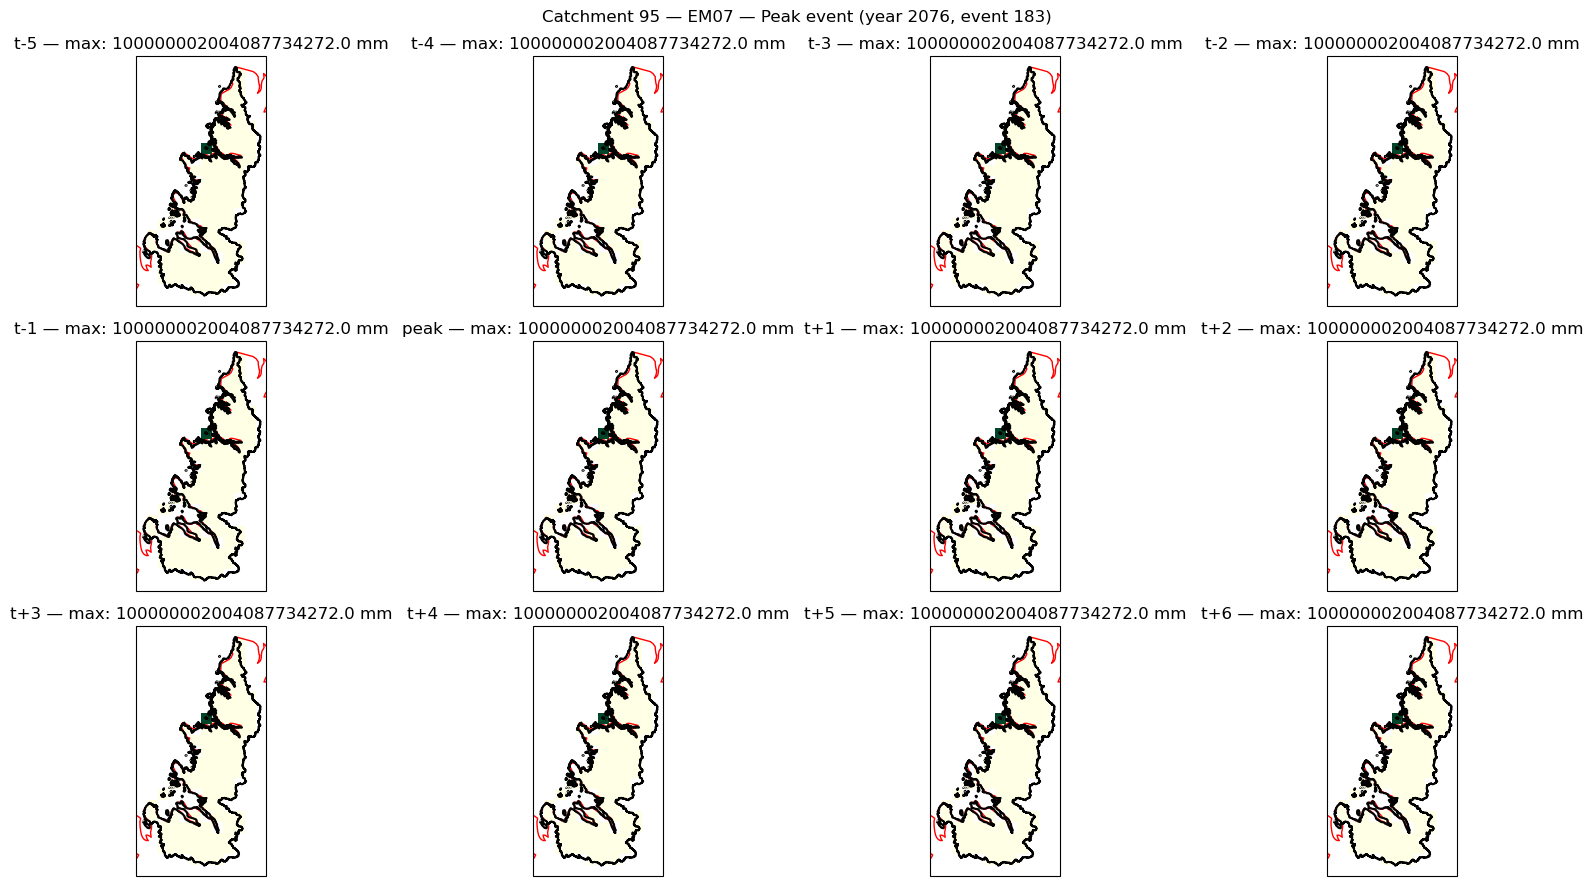

In [10]:
plot_surrounding_ts_new(rainfall_cube_dir_bc, catchment_num, ens_num, bc=True)

<div style="background-color: #e8f4f8; color: black; border-left: 4px solid steelblue; 
padding: 10px 20px; border-radius: 0px 5px 5px 0px; margin: 10px 20px;">
What happens if plot same plot using data that hasn't been bias corrected? 

</div>

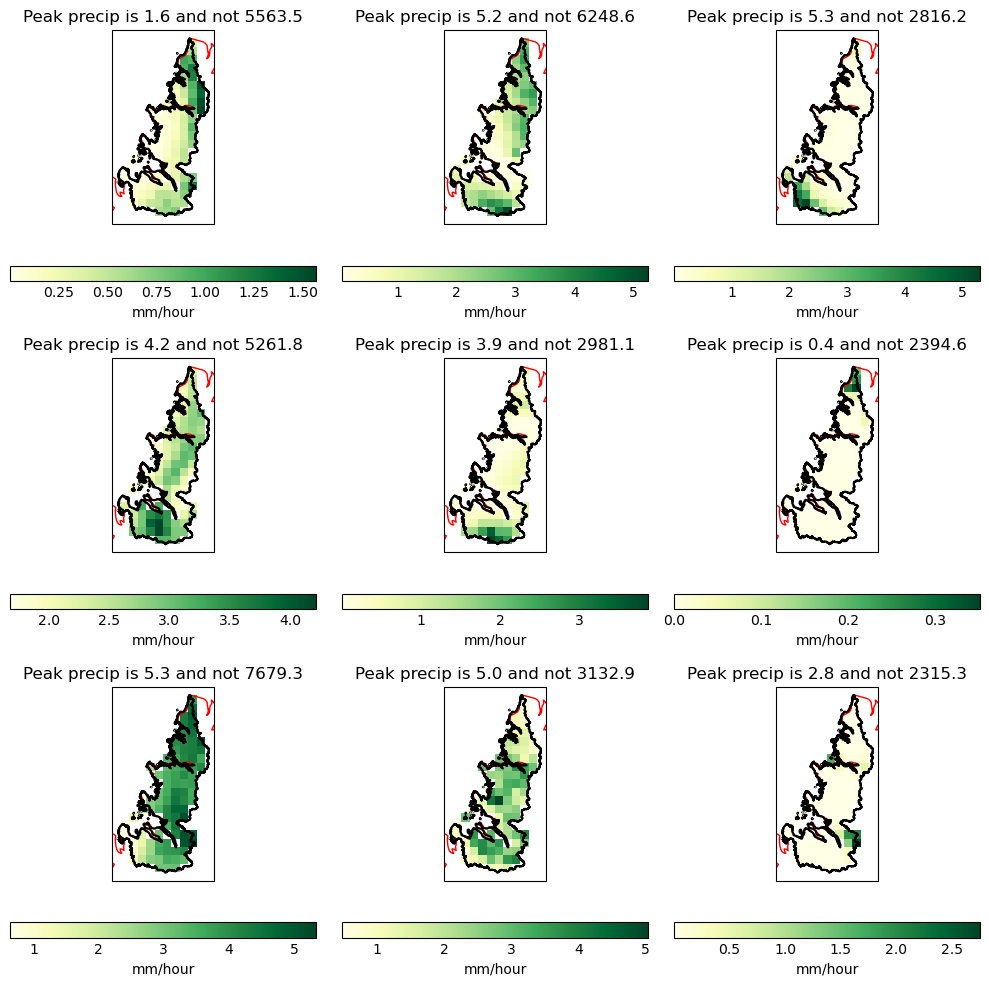

In [11]:
plot_n_peaks(rainfall_cube_dir_notbc, ens_num = ens_num, catchment_num= catchment_num, n= 9, bc=False)